In [ ]:
# Week 2: Data Collection, Cleaning and Preprocessing
# E-Commerce Delivery Optimization Using Data Science

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("Delivery_Logistics.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (25000, 15)


In [4]:
df.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600


In [5]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_id          25000 non-null  float64
 1   delivery_partner     25000 non-null  object 
 2   package_type         25000 non-null  object 
 3   vehicle_type         25000 non-null  object 
 4   delivery_mode        25000 non-null  object 
 5   region               25000 non-null  object 
 6   weather_condition    25000 non-null  object 
 7   distance_km          25000 non-null  float64
 8   package_weight_kg    25000 non-null  float64
 9   delivery_time_hours  25000 non-null  object 
 10  expected_time_hours  25000 non-null  object 
 11  delayed              25000 non-null  object 
 12  delivery_status      25000 non-null  object 
 13  delivery_rating      25000 non-null  int64  
 14  delivery_cost        25000 non-null  float64
dtypes: float64(4), 

In [6]:
df.describe(include="all")

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
count,25000.000000,25000,25000,25000,25000,25000,25000,25000.000000,25000.000000,25000,25000,25000,25000,25000.000000,25000.000000
unique,NaN,9,9,6,4,5,6,NaN,NaN,20,9,2,3,NaN,NaN
top,NaN,xpressbees,fragile items,ev bike,two day,west,foggy,NaN,NaN,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000016,no,delivered,NaN,NaN
freq,NaN,2826,2848,4218,6302,5095,4219,NaN,NaN,3118,6302,18331,18331,NaN,NaN
mean,12500.500000,NaN,NaN,NaN,NaN,NaN,NaN,150.390436,25.145898,NaN,NaN,NaN,NaN,3.666000,864.944579
std,7212.732314,NaN,NaN,NaN,NaN,NaN,NaN,86.409745,14.368663,NaN,NaN,NaN,NaN,1.149964,435.712593
min,250.990000,NaN,NaN,NaN,NaN,NaN,NaN,3.600000,0.670000,NaN,NaN,NaN,NaN,1.000000,95.667400
25%,6250.750000,NaN,NaN,NaN,NaN,NaN,NaN,75.900000,12.680000,NaN,NaN,NaN,NaN,3.000000,490.800000
50%,12500.500000,NaN,NaN,NaN,NaN,NaN,NaN,151.000000,25.145000,NaN,NaN,NaN,NaN,4.000000,867.535000
75%,18750.250000,NaN,NaN,NaN,NaN,NaN,NaN,224.900000,37.660000,NaN,NaN,NaN,NaN,5.000000,1237.910000


In [7]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
delivery_id            0
delivery_partner       0
package_type           0
vehicle_type           0
delivery_mode          0
region                 0
weather_condition      0
distance_km            0
package_weight_kg      0
delivery_time_hours    0
expected_time_hours    0
delayed                0
delivery_status        0
delivery_rating        0
delivery_cost          0
dtype: int64


In [8]:
print("Number of duplicate records:", df.duplicated().sum())

Number of duplicate records: 0


In [9]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['delivery_id', 'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'distance_km', 'package_weight_kg', 'delivery_time_hours', 'expected_time_hours', 'delayed', 'delivery_status', 'delivery_rating', 'delivery_cost']


In [10]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 25000
Number of Columns: 15


In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing Value Percentage:")
print(missing_percentage)

Missing Value Percentage:
delivery_id            0.0
delivery_partner       0.0
package_type           0.0
vehicle_type           0.0
delivery_mode          0.0
region                 0.0
weather_condition      0.0
distance_km            0.0
package_weight_kg      0.0
delivery_time_hours    0.0
expected_time_hours    0.0
delayed                0.0
delivery_status        0.0
delivery_rating        0.0
delivery_cost          0.0
dtype: float64


In [12]:
print("Data Types of Each Column:")
print(df.dtypes)

Data Types of Each Column:
delivery_id            float64
delivery_partner        object
package_type            object
vehicle_type            object
delivery_mode           object
region                  object
weather_condition       object
distance_km            float64
package_weight_kg      float64
delivery_time_hours     object
expected_time_hours     object
delayed                 object
delivery_status         object
delivery_rating          int64
delivery_cost          float64
dtype: object


In [13]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (25000, 15)


In [14]:
categorical_columns = [
    "delivery_partner",
    "package_type",
    "vehicle_type",
    "delivery_mode",
    "region",
    "weather_condition",
    "delayed",
    "delivery_status"
]

for column in categorical_columns:
    print("\n", column)
    print(df[column].unique())


 delivery_partner
['delhivery' 'xpressbees' 'shadowfax' 'dhl' 'amazon logistics' 'blue dart'
 'fedex' 'ecom express' 'ekart']

 package_type
['automobile parts' 'cosmetics' 'groceries' 'electronics' 'clothing'
 'documents' 'fragile items' 'pharmacy' 'furniture']

 vehicle_type
['bike' 'ev van' 'truck' 'van' 'ev bike' 'scooter']

 delivery_mode
['same day' 'express' 'two day' 'standard']

 region
['west' 'central' 'east' 'north' 'south']

 weather_condition
['clear' 'cold' 'rainy' 'foggy' 'hot' 'stormy']

 delayed
['no' 'yes']

 delivery_status
['delivered' 'delayed' 'failed']


In [15]:
for column in categorical_columns:
    df[column] = (
        df[column]
        .astype(str)
        .str.strip()
        .str.lower()
    )

print("Categorical values standardized successfully.")

Categorical values standardized successfully.


In [16]:
numerical_columns = [
    "distance_km",
    "package_weight_kg",
    "delivery_time_hours",
    "expected_time_hours",
    "delivery_rating",
    "delivery_cost"
]

for column in numerical_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

print(df[numerical_columns].dtypes)

distance_km            float64
package_weight_kg      float64
delivery_time_hours    float64
expected_time_hours    float64
delivery_rating          int64
delivery_cost          float64
dtype: object


In [17]:
for column in numerical_columns:
    df[column] = df[column].fillna(
        df[column].median()
    )

print("Missing numerical values handled.")

Missing numerical values handled.


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [18]:
for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(
            df[column].mode()[0]
        )

print("Missing categorical values handled.")

Missing categorical values handled.


In [19]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
delivery_id                0
delivery_partner           0
package_type               0
vehicle_type               0
delivery_mode              0
region                     0
weather_condition          0
distance_km                0
package_weight_kg          0
delivery_time_hours    25000
expected_time_hours    25000
delayed                    0
delivery_status            0
delivery_rating            0
delivery_cost              0
dtype: int64


In [20]:
print("Median values:")

print("Delivery Time Median:",
      df["delivery_time_hours"].median())

print("Expected Time Median:",
      df["expected_time_hours"].median())

print("\nMissing values:")
print(df[["delivery_time_hours", "expected_time_hours"]].isnull().sum())

Median values:
Delivery Time Median: nan
Expected Time Median: nan

Missing values:
delivery_time_hours    25000
expected_time_hours    25000
dtype: int64


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [21]:
print(df[[
    "delivery_time_hours",
    "expected_time_hours"
]].describe())

       delivery_time_hours  expected_time_hours
count                  0.0                  0.0
mean                   NaN                  NaN
std                    NaN                  NaN
min                    NaN                  NaN
25%                    NaN                  NaN
50%                    NaN                  NaN
75%                    NaN                  NaN
max                    NaN                  NaN


In [22]:
print("Missing values:")
print(df[[
    "delivery_time_hours",
    "expected_time_hours"
]].isnull().sum())

print("\nTotal rows:")
print(len(df))

print("\nNon-missing values:")
print(df[[
    "delivery_time_hours",
    "expected_time_hours"
]].notnull().sum())

Missing values:
delivery_time_hours    25000
expected_time_hours    25000
dtype: int64

Total rows:
25000

Non-missing values:
delivery_time_hours    0
expected_time_hours    0
dtype: int64


In [23]:
empty_columns = df.columns[df.isnull().all()]

print("Completely empty columns:")
print(empty_columns.tolist())

df = df.drop(columns=empty_columns)

print("\nDataset shape after removing empty columns:")
print(df.shape)

Completely empty columns:
['delivery_time_hours', 'expected_time_hours']

Dataset shape after removing empty columns:
(25000, 13)


In [24]:
print("Missing values after removing completely empty columns:")
print(df.isnull().sum())

Missing values after removing completely empty columns:
delivery_id          0
delivery_partner     0
package_type         0
vehicle_type         0
delivery_mode        0
region               0
weather_condition    0
distance_km          0
package_weight_kg    0
delayed              0
delivery_status      0
delivery_rating      0
delivery_cost        0
dtype: int64


In [25]:
print("Numerical Columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

Numerical Columns:
['delivery_id', 'distance_km', 'package_weight_kg', 'delivery_rating', 'delivery_cost']


In [26]:
df.describe()

,delivery_id,distance_km,package_weight_kg,delivery_rating,delivery_cost
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12500.500000,150.390436,25.145898,3.666000,864.944579
std,7212.732314,86.409745,14.368663,1.149964,435.712593
min,250.990000,3.600000,0.670000,1.000000,95.667400
25%,6250.750000,75.900000,12.680000,3.000000,490.800000
50%,12500.500000,151.000000,25.145000,4.000000,867.535000
75%,18750.250000,224.900000,37.660000,5.000000,1237.910000
max,24750.010000,297.100000,49.520000,5.000000,1632.720600


In [27]:
numerical_columns = df.select_dtypes(include=np.number).columns

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]
    
    print(f"{column}: {len(outliers)} outliers")

delivery_id: 0 outliers
distance_km: 0 outliers
package_weight_kg: 0 outliers
delivery_rating: 0 outliers
delivery_cost: 0 outliers


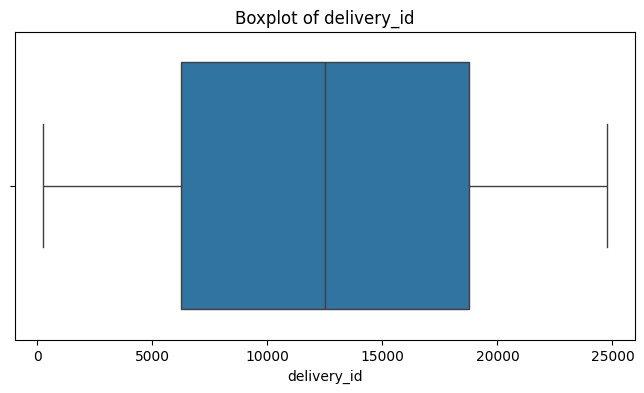

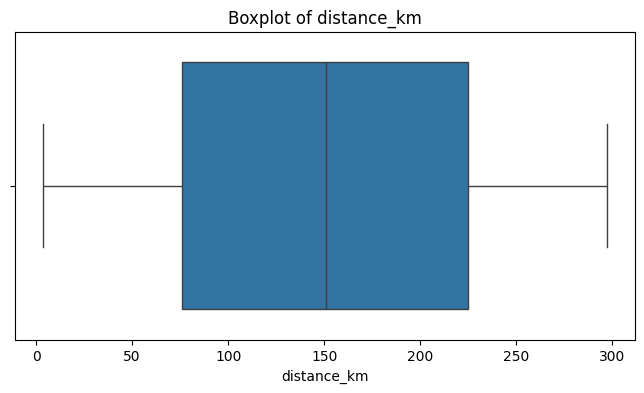

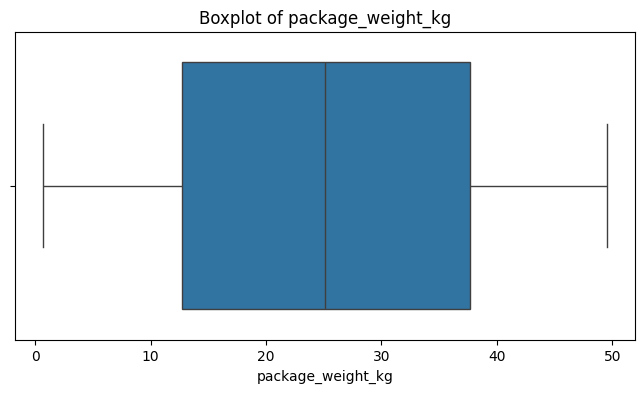

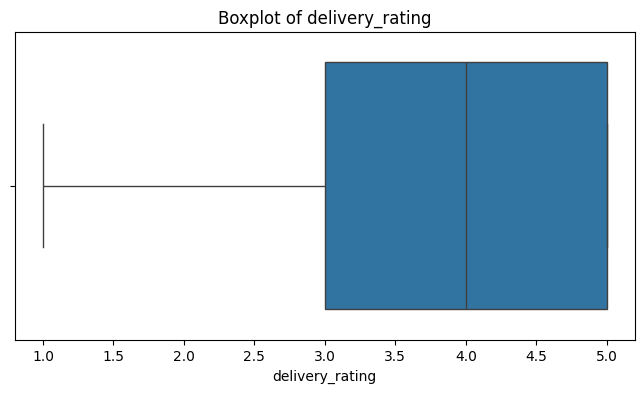

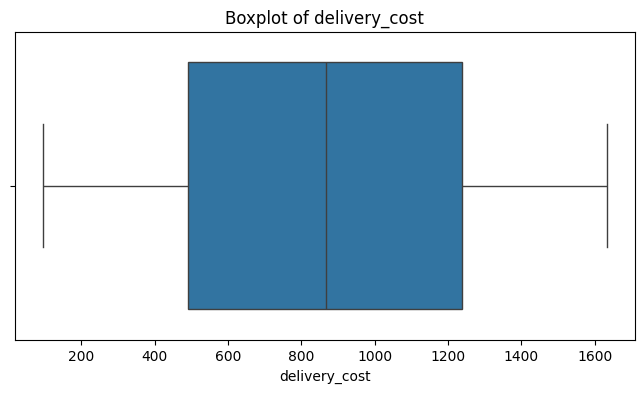

In [28]:
for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

In [29]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

columns_to_normalize = [
    "distance_km",
    "package_weight_kg",
    "delivery_rating",
    "delivery_cost"
]

df[columns_to_normalize] = scaler.fit_transform(
    df[columns_to_normalize]
)

print("Normalization completed successfully!")

Normalization completed successfully!


In [30]:
print(df[columns_to_normalize].describe())

        distance_km  package_weight_kg  delivery_rating  delivery_cost
count  25000.000000       25000.000000     25000.000000   25000.000000
mean       0.500138           0.501042         0.666500       0.500488
std        0.294411           0.294138         0.287491       0.283473
min        0.000000           0.000000         0.000000       0.000000
25%        0.246337           0.245855         0.500000       0.257072
50%        0.502215           0.501024         0.750000       0.502174
75%        0.754003           0.757216         1.000000       0.743138
max        1.000000           1.000000         1.000000       1.000000


In [31]:
df["cost_per_km"] = np.where(
    df["distance_km"] != 0,
    df["delivery_cost"] / df["distance_km"],
    0
)

print(df[[
    "distance_km",
    "delivery_cost",
    "cost_per_km"
]].head())

   distance_km  delivery_cost  cost_per_km
0     0.999659       1.000000     1.000341
1     0.293015       0.354251     1.208984
2     0.919591       0.879932     0.956873
3     0.906644       0.904915     0.998093
4     0.862351       0.845054     0.979942


In [32]:
df["delay_flag"] = df["delayed"].astype(str).str.lower().map({
    "yes": 1,
    "no": 0,
    "true": 1,
    "false": 0,
    "1": 1,
    "0": 0
})

print(df["delay_flag"].value_counts(dropna=False))

delay_flag
0    18331
1     6669
Name: count, dtype: int64


In [34]:
print("Final Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFirst 5 Rows:")
display(df.head())

Final Dataset Shape: (25000, 15)

Missing Values:
delivery_id          0
delivery_partner     0
package_type         0
vehicle_type         0
delivery_mode        0
region               0
weather_condition    0
distance_km          0
package_weight_kg    0
delayed              0
delivery_status      0
delivery_rating      0
delivery_cost        0
cost_per_km          0
delay_flag           0
dtype: int64

First 5 Rows:


,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_status,delivery_rating,delivery_cost,cost_per_km,delay_flag
0,250.99,delhivery,automobile parts,bike,same day,west,clear,0.999659,0.947595,no,delivered,0.50,1.000000,1.000341,0
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,0.293015,0.956397,no,delivered,1.00,0.354251,1.208984,0
2,250.99,shadowfax,groceries,truck,two day,east,rainy,0.919591,0.536745,no,delivered,0.75,0.879932,0.956873,0
3,250.99,dhl,electronics,ev van,same day,east,cold,0.906644,0.246059,no,delivered,0.50,0.904915,0.998093,0
4,250.99,dhl,clothing,van,two day,north,foggy,0.862351,0.744115,no,delivered,0.75,0.845054,0.979942,0


In [35]:
df.to_csv("cleaned_logistics_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
